# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## Additional part for me, just understdanding dataset and its functionalities

In [10]:
mpg.sort_values('cylinders',ascending=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
334,23.7,3,70.0,100.0,2420,12.5,80,japan,mazda rx-7 gs
243,21.5,3,80.0,110.0,2720,13.5,77,japan,mazda rx-4
111,18.0,3,70.0,90.0,2124,13.5,73,japan,maxda rx3
71,19.0,3,70.0,97.0,2330,13.5,72,japan,mazda rx2 coupe
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
...,...,...,...,...,...,...,...,...,...
41,14.0,8,318.0,150.0,4096,13.0,71,usa,plymouth fury iii
40,14.0,8,351.0,153.0,4154,13.5,71,usa,ford galaxie 500
39,14.0,8,400.0,175.0,4464,11.5,71,usa,pontiac catalina brougham
43,13.0,8,400.0,170.0,4746,12.0,71,usa,ford country squire (sw)


In [3]:
mpg['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [5]:
mpg['cylinders'].unique()

array([8, 4, 6, 3, 5])

In [6]:
mpg['model_year'].unique()

array([70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82])

In [9]:
print(mpg[mpg['origin']=='usa'].count())
print(mpg[mpg['origin']=='japan'].count())
print(mpg[mpg['origin']=='europe'].count())

mpg             245
cylinders       245
displacement    245
horsepower      245
weight          245
acceleration    245
model_year      245
origin          245
name            245
dtype: int64
mpg             79
cylinders       79
displacement    79
horsepower      79
weight          79
acceleration    79
model_year      79
origin          79
name            79
dtype: int64
mpg             68
cylinders       68
displacement    68
horsepower      68
weight          68
acceleration    68
model_year      68
origin          68
name            68
dtype: int64


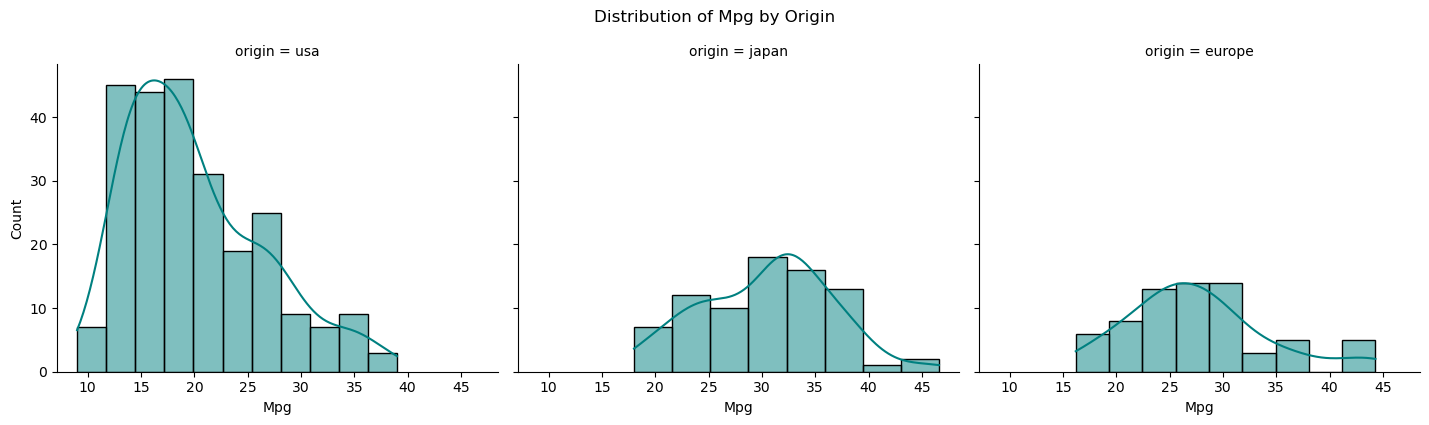

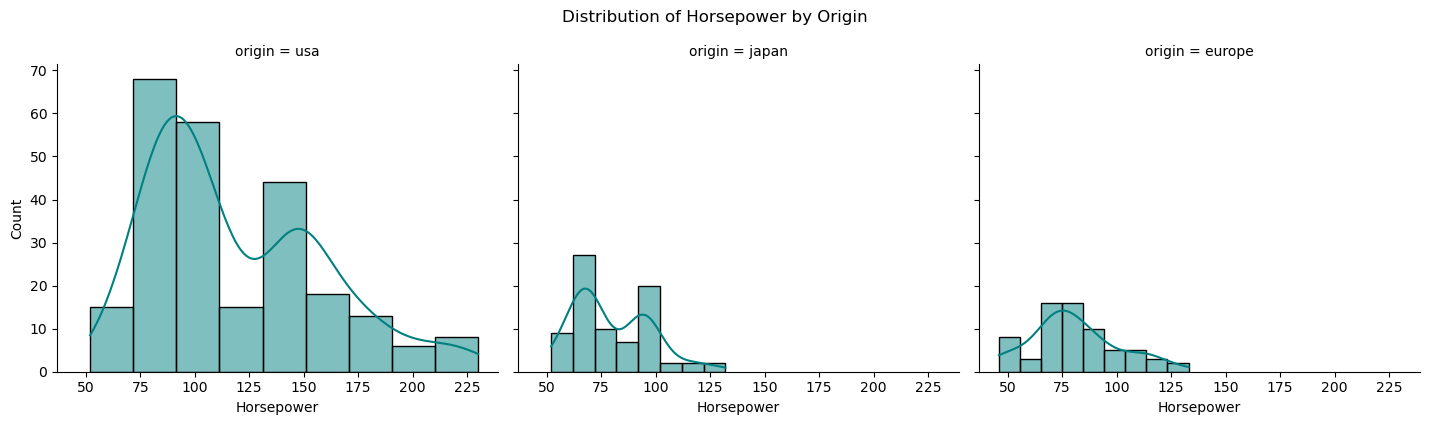

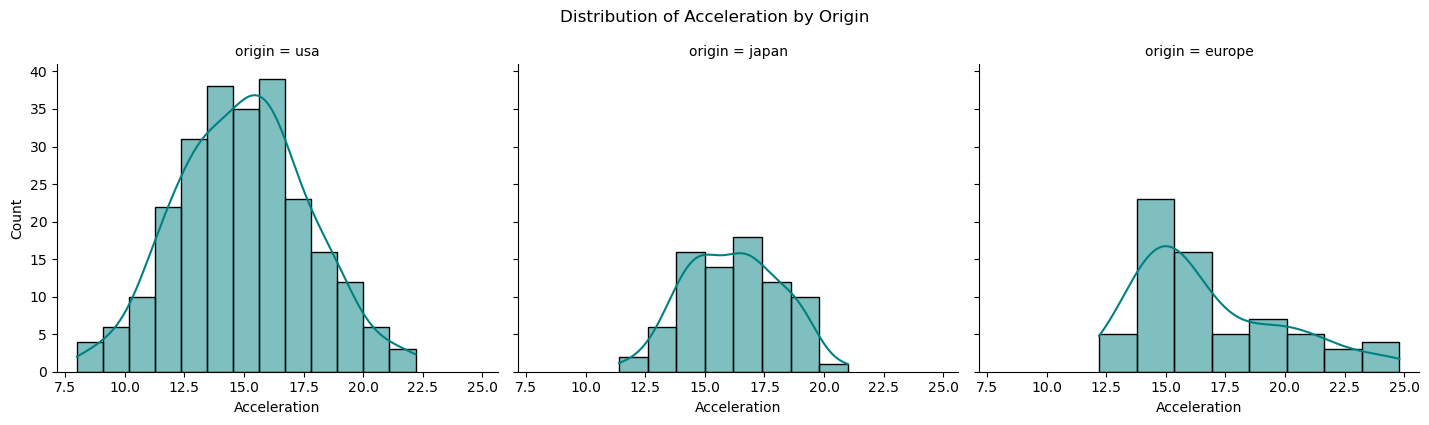

In [7]:
features = ['mpg', 'horsepower', 'acceleration']

for feature in features:
    g = sns.FacetGrid(mpg, col="origin", height=4, aspect=1.2)
    g.map(sns.histplot, feature, kde=True, color="teal")
    
    g.set_axis_labels(feature.capitalize(), "Count")
    g.fig.suptitle(f'Distribution of {feature.capitalize()} by Origin', y=1.05)
    
    plt.show()

---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

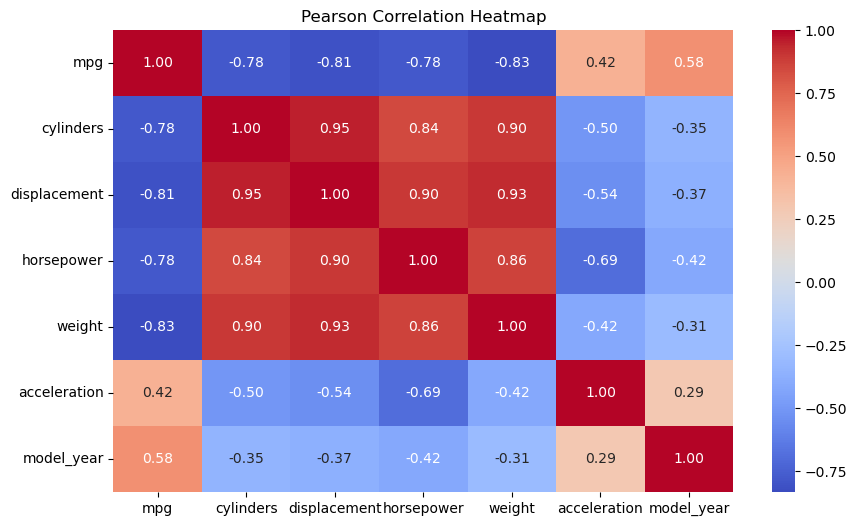

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(mpg.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.show()

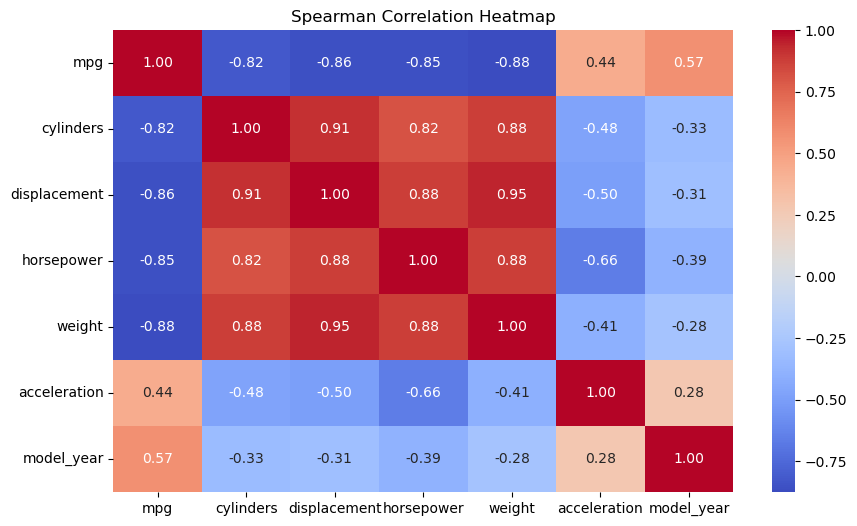

In [32]:
plt.figure(figsize=(10, 6))

spearman_corr = mpg.corr(method='spearman', numeric_only=True)

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

it can be *multicollinarity* and can be cause some problems for our model

cylinders ↔ displacement: 0.96(spearman)  ⚠️

cylinders ↔ weight:        0.90(pearson)  ⚠️

displacement ↔ weight:     0.94(spearman)  ⚠️

displacement ↔ horsepower: 0.90(pearson)  ⚠️

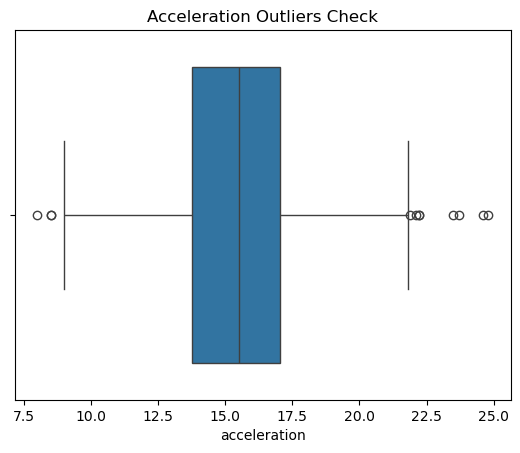

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=mpg['acceleration'])
plt.title("Acceleration Outliers Check")
plt.show()

# my pairs

mpg ↔ weight: While the Pearson correlation is -0.83, the Spearman correlation is even stronger at -0.88. This suggests a very strong monotonic relationship, where fuel efficiency decreases as weight increases, but the relationship may be slightly non-linear.

mpg ↔ horsepower: Similarly, the Spearman correlation (-0.85) is notably higher than Pearson (-0.78). This indicates that the impact of horsepower on fuel consumption is better captured by rank-order, likely due to some non-linear patterns or outliers in high-performance engines.

mpg ↔ model_year (0.58): Both Pearson and Spearman coefficients are nearly identical here. This confirms a consistent and steady linear improvement in fuel efficiency as technology advanced year over year.

mpg ↔ acceleration (0.42): This remains the weakest correlation. It confirms that acceleration is a complex metric influenced by multiple variables beyond just engine efficiency, such as gear ratios and weight distribution.

These pairs were selected based on their correlation 
strength with the target variable (MPG). High-correlation 
features (weight: -0.83, horsepower: -0.78) were prioritized 
to visualize the most impactful relationships.

In [21]:
import pandas as pd
import seaborn as sns
from scipy import stats

mpg = sns.load_dataset("mpg").dropna()

pairs = [
    ('mpg', 'weight'),
    ('mpg', 'horsepower'),
    ('model_year', 'mpg'),
    ('mpg', 'acceleration')
]

print(f"{'Variables':<25} | {'Pearson r':<12} | {'Spearman rho':<12} | {'Difference'}")
print("-" * 70)

for var1, var2 in pairs:
    p_r, _ = stats.pearsonr(mpg[var1], mpg[var2])
    s_rho, _ = stats.spearmanr(mpg[var1], mpg[var2])
    
    diff = abs(p_r - s_rho)
    
    print(f"{var1 + ' vs ' + var2:<25} | {p_r:>12.3f} | {s_rho:>12.3f} | {diff:>10.3f}")

Variables                 | Pearson r    | Spearman rho | Difference
----------------------------------------------------------------------
mpg vs weight             |       -0.832 |       -0.876 |      0.043
mpg vs horsepower         |       -0.778 |       -0.854 |      0.075
model_year vs mpg         |        0.581 |        0.575 |      0.006
mpg vs acceleration       |        0.423 |        0.442 |      0.018


Pearson assumes linear relationships and normal distribution.
Spearman is rank-based and captures non-linear monotonic 
relationships. Both were computed to verify consistency — 
where Spearman and Pearson differ significantly, 
a non-linear relationship likely exists.

In [24]:
from scipy import stats

pairs = [
    ('mpg', 'weight'),
    ('mpg', 'horsepower'),
    ('model_year', 'mpg'),
    ('mpg', 'acceleration')
]

print(f"{'Variables':<30} | {'Pearson r':<10} | {'p-value':<10}")
print("-" * 55)

for var1, var2 in pairs:
    r, p = stats.pearsonr(mpg[var1], mpg[var2])
    
    print(f"{var1 + ' vs ' + var2:<30} | {r:>10.3f} | {p:>10.2e}")

Variables                      | Pearson r  | p-value   
-------------------------------------------------------
mpg vs weight                  |     -0.832 |  6.02e-102
mpg vs horsepower              |     -0.778 |   7.03e-81
model_year vs mpg              |      0.581 |   1.08e-36
mpg vs acceleration            |      0.423 |   1.78e-18


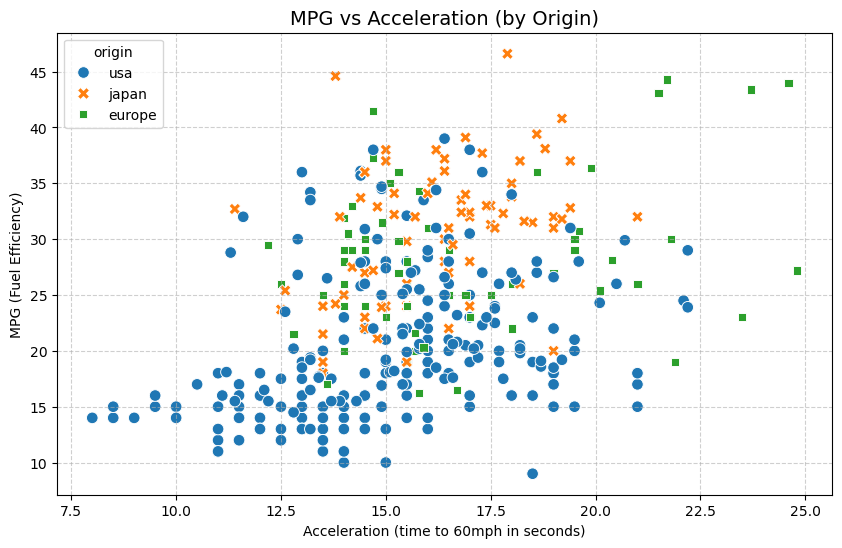

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

mpg = sns.load_dataset("mpg").dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=mpg, x='acceleration', y='mpg', hue='origin', style='origin', s=70)

plt.title('MPG vs Acceleration (by Origin)', fontsize=14)
plt.xlabel('Acceleration (time to 60mph in seconds)')
plt.ylabel('MPG (Fuel Efficiency)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [30]:
import pingouin as pg

# model_year is important factor
# acceleration → mpg relation
partial = pg.partial_corr(data=mpg, 
                           x='acceleration', 
                           y='mpg', 
                           covar='model_year')
print(partial)

           n         r          CI95         p_val
pearson  392  0.327002  [0.24, 0.41]  3.392175e-11


The positive correlation between acceleration and mpg ($r \approx 0.42$) is a classic example of a spurious relationship driven by a confounding variable: model_year. From a purely physical standpoint, better performance (faster acceleration) typically requires higher fuel consumption. However, in this dataset, we observe both metrics improving simultaneously. This occurs because technological advancements over the period (1970–1982) allowed newer engines to become both more efficient and more powerful at the same time. Therefore, the correlation is not due to a direct causal link between acceleration and efficiency, but rather a shared dependency on time-based engineering progress

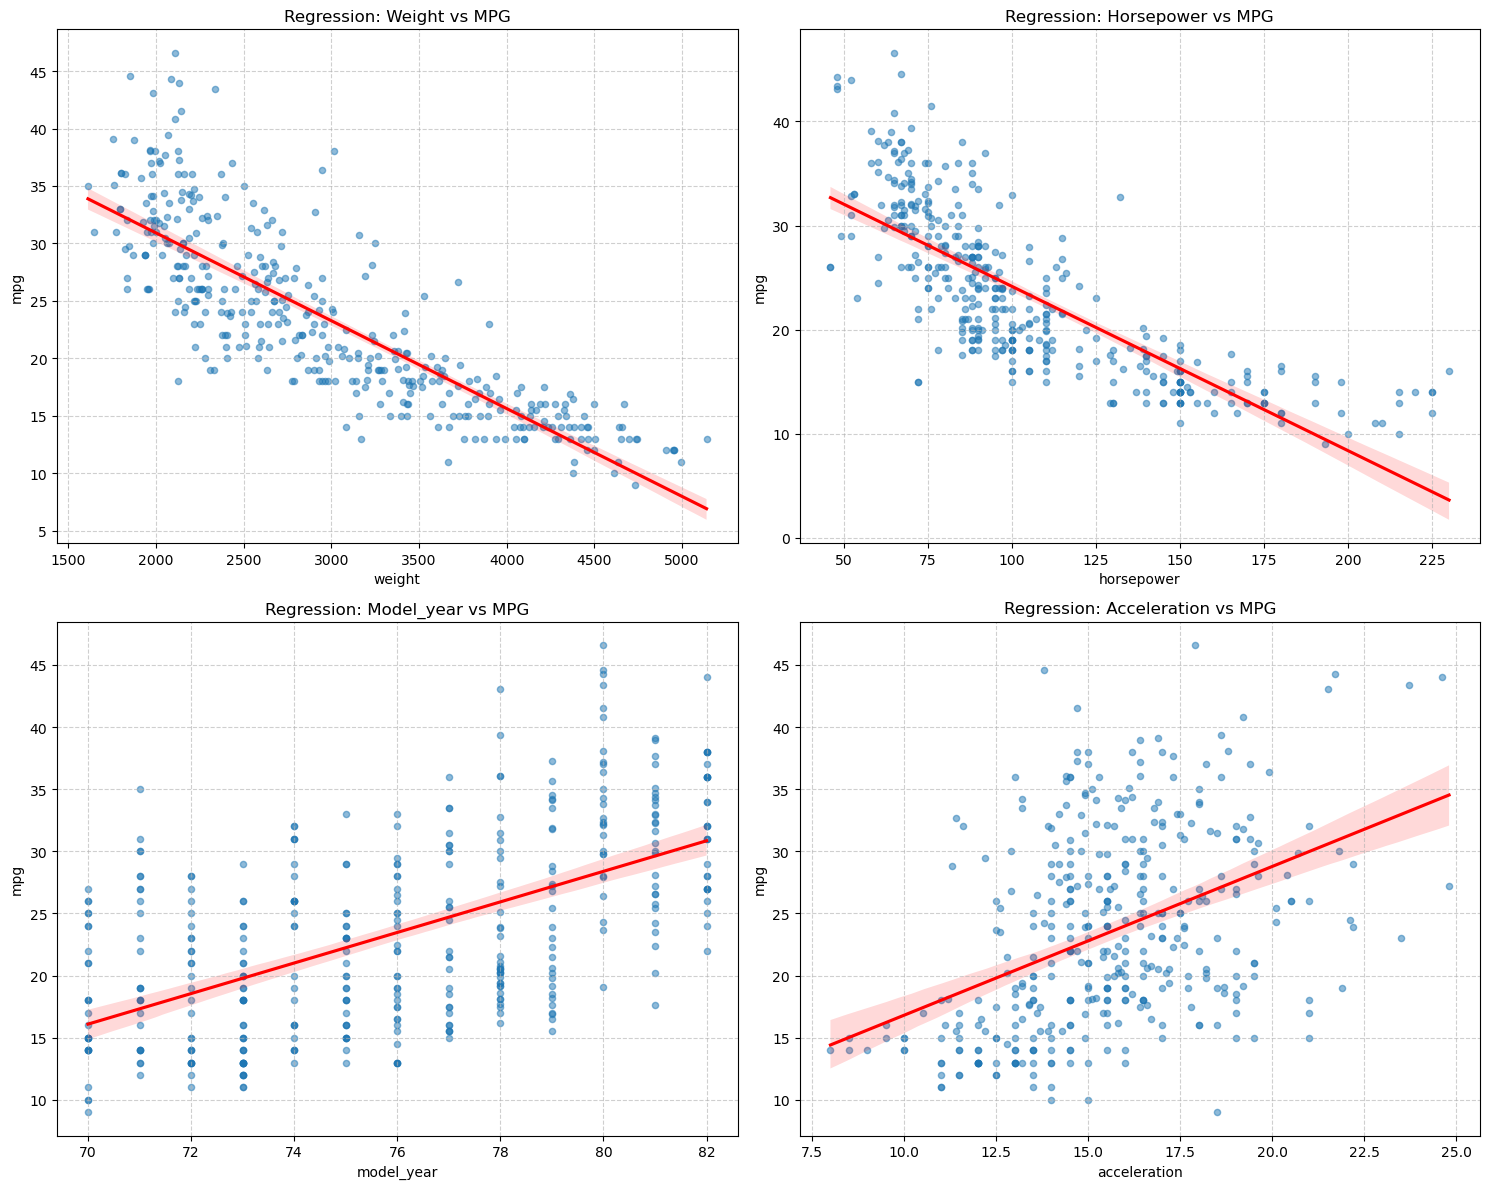

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

mpg = sns.load_dataset("mpg").dropna()

pairs = [
    ('weight', 'mpg'),
    ('horsepower', 'mpg'),
    ('model_year', 'mpg'),
    ('acceleration', 'mpg')
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (x_var, y_var) in enumerate(pairs):
    sns.regplot(data=mpg, x=x_var, y=y_var, ax=axes[i], 
                scatter_kws={'alpha':0.5, 's':20}, 
                line_kws={'color':'red'})
    axes[i].set_title(f'Regression: {x_var.capitalize()} vs {y_var.upper()}')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Pearson correlation is most appropriate for linear relationships between normally distributed variables, while Spearman is better suited for non-linear, monotonic relationships and is more robust to outliers.

In my results, model_year vs mpg shows nearly identical coefficients (Pearson: 0.581, Spearman: 0.575), indicating a consistent linear trend. However, for mpg vs horsepower and mpg vs weight, the Spearman coefficients are significantly stronger (e.g., -0.854 vs -0.778 for horsepower). This indicates that engine power and weight have a non-linear, curved relationship with fuel efficiency, which Spearman captures more effectively by focusing on rank-order rather than exact values. Additionally, Spearman's higher values across most pairs suggest the presence of outliers that weaken the Pearson correlation.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31292\850060458.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mpg, x='origin', y='mpg', palette='Pastel1', inner="quartile")


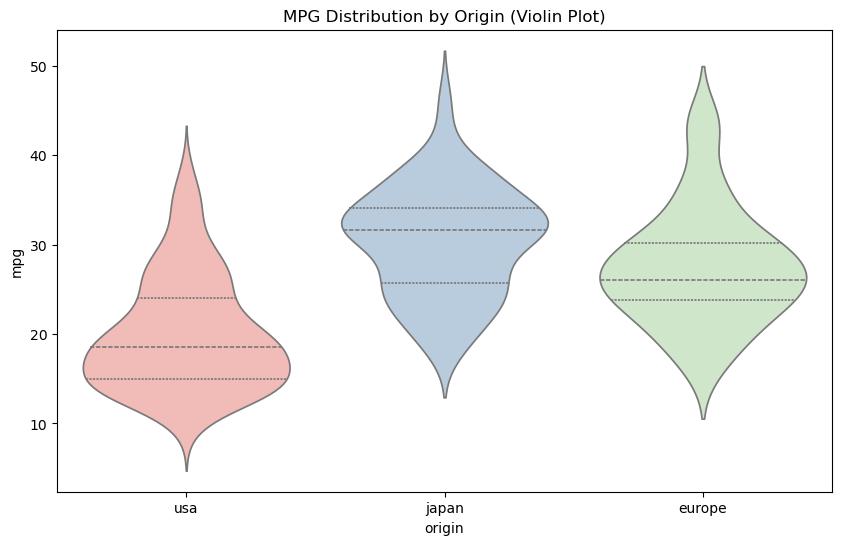

In [37]:
# Distribution visualization by origin
import seaborn as sns
import matplotlib.pyplot as plt

#Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=mpg, x='origin', y='mpg', palette='Pastel1', inner="quartile")
plt.title('MPG Distribution by Origin (Violin Plot)')
plt.show()

In [38]:
# Assumption checks: Shapiro-Wilk + Levene's test



usa_mpg = mpg[mpg['origin'] == 'usa']['mpg']
japan_mpg = mpg[mpg['origin'] == 'japan']['mpg']
europe_mpg = mpg[mpg['origin'] == 'europe']['mpg']

# A. Shapiro-Wilk 
print("--- Shapiro-Wilk Test Results (Normality) ---")
for name, data in [("USA", usa_mpg), ("Japan", japan_mpg), ("Europe", europe_mpg)]:
    stat, p_value = stats.shapiro(data)
    status = "Normal" if p_value > 0.05 else "Not Normal"
    print(f"{name:<7}: p-value = {p_value:.4f} ({status})")

print("\n" + "="*45 + "\n")

# B. Levene's Test 
print("--- Levene's Test Results (Equal Variances) ---")
stat_lev, p_val_lev = stats.levene(usa_mpg, japan_mpg, europe_mpg)
lev_status = "Equal" if p_val_lev > 0.05 else "Not Equal"
print(f"Levene p-value = {p_val_lev:.4f} (Variances are {lev_status})")

--- Shapiro-Wilk Test Results (Normality) ---
USA    : p-value = 0.0000 (Not Normal)
Japan  : p-value = 0.2420 (Normal)
Europe : p-value = 0.0054 (Not Normal)


--- Levene's Test Results (Equal Variances) ---
Levene p-value = 0.9175 (Variances are Equal)


In [40]:
# One-way ANOVA
# 1. ANOVA — just task wants
stat, p_value = stats.f_oneway(usa_mpg, japan_mpg, europe_mpg)
print(f"ANOVA: p-value = {p_value:.4e}")

# 2. Kruskal-Wallis — correct one
stat, p_value = stats.kruskal(usa_mpg, japan_mpg, europe_mpg)
print(f"Kruskal-Wallis: p-value = {p_value:.4e}")

ANOVA: p-value = 8.6738e-35
Kruskal-Wallis: p-value = 2.0782e-29


In [42]:
from scipy import stats
import numpy as np

# Kruskal-Wallis
stat, p_value = stats.kruskal(usa_mpg, japan_mpg, europe_mpg)

# Effect size — Epsilon squared
n = len(usa_mpg) + len(japan_mpg) + len(europe_mpg)
k = 3  # group count
epsilon_squared = (stat - k + 1) / (n - k)

print(f"H-statistic : {stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print(f"Epsilon²    : {epsilon_squared:.4f}")

H-statistic : 132.0870
p-value     : 0.0000
Epsilon²    : 0.3344


Although Shapiro-Wilk indicated non-normality for USA 
and Europe groups, one-way ANOVA was computed as required.
However, given the violated normality assumption, 
Kruskal-Wallis is the statistically appropriate test.
Effect size was measured using Epsilon-squared (ε² = 0.33),
the non-parametric equivalent of eta-squared,
indicating a large effect

According to the Shapiro-Wilk test results, the mpg distributions for USA and Europe do not follow a normal distribution ($p < 0.05$). Since the assumption of normality is violated, the results of a standard One-Way ANOVA may be unreliable and biased.

To ensure statistical validity, I have opted to use the Kruskal-Wallis H-test, which is the non-parametric alternative to ANOVA. This test does not require the data to be normally distributed as it ranks the observations rather than comparing their means. This approach provides a more robust and accurate comparison of fuel efficiency across the three regions.

In [41]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

tukey = pairwise_tukeyhsd(
    endog=mpg['mpg'],
    groups=mpg['origin'],
    alpha=0.05
)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

The Kruskal-Wallis (H=132.09, p<0.001) and Tukey HSD results collectively indicate:

The differences in MPG among all three regions are real and statistically significant.

The largest difference is between Japan and the USA (+10.42 MPG) — Japanese cars are significantly more efficient.

Europe and Japan show similar performance, but there is still a real difference between them (2.85 MPG).

The effect size (ε²=0.33) suggests that origin can be a strong predictor of MPG — however, it does not explain it entirely on its own; factors like weight and horsepower are also critical.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


**there is imbalanced dataset here**

In [47]:
# Train classifiers and generate predictions
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# ── 1. Modells ──────────────────────────────────────
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED
)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=SEED
)

# ── 2. Train ─────────────────────────────────────────
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# ── 3. Predict ───────────────────────────────────────
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)



C:\Users\ASUS\anaconda3\envs\ironhack\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
# Classification reports
print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, lr_preds))

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, rf_preds))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

      europe       0.58      0.65      0.61        17
       japan       0.61      0.70      0.65        20
         usa       0.96      0.89      0.92        61

    accuracy                           0.81        98
   macro avg       0.72      0.74      0.73        98
weighted avg       0.82      0.81      0.81        98

RANDOM FOREST
              precision    recall  f1-score   support

      europe       0.75      0.71      0.73        17
       japan       0.79      0.75      0.77        20
         usa       0.95      0.98      0.97        61

    accuracy                           0.89        98
   macro avg       0.83      0.81      0.82        98
weighted avg       0.88      0.89      0.89        98



<Figure size 800x600 with 0 Axes>

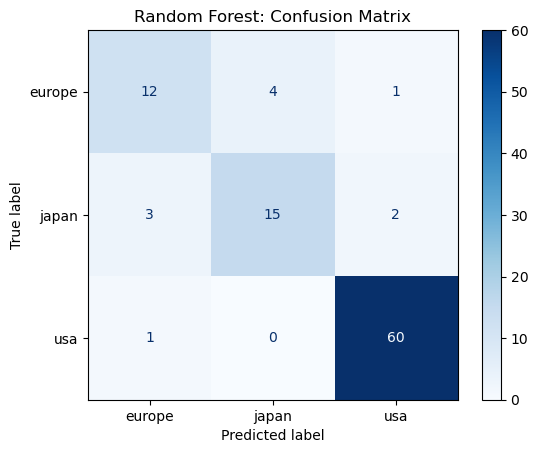

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# for Random Forest 
cm = confusion_matrix(y_test, rf_preds, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title("Random Forest: Confusion Matrix")
plt.show()

In [50]:


def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    boot_scores = []
    
    # 1. Nöqtəvi təxmin (Orijinal test seti üzərində nəticə)
    point_estimate = metric_fn(y_true, y_pred)
    
    indices = np.arange(len(y_true))
    
    for _ in range(n_boot):
        # 2. Resampling (Datanı əvəzləmə şərti ilə təsadüfi seçirik)
        resample_idx = rng.choice(indices, size=len(indices), replace=True)
        
        # 3. Hər bootstrap nümunəsi üçün metriki hesablayırıq
        score = metric_fn(y_true[resample_idx], y_pred[resample_idx])
        boot_scores.append(score)
    
    boot_scores = np.array(boot_scores)
    
    # 4. 95% Güvən aralığını hesablayırıq (2.5-ci və 97.5-ci persentillər)
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)
    
    return point_estimate, ci_lower, ci_upper, boot_scores

In [52]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd


metrics_to_compute = {
    "F1 (Macro)": lambda yt, yp: f1_score(yt, yp, average='macro'),
    "Precision (Macro)": lambda yt, yp: precision_score(yt, yp, average='macro', zero_division=0),
    "Recall (Macro)": lambda yt, yp: recall_score(yt, yp, average='macro')
}

model_predictions = {
    "Logistic Regression": lr_preds,
    "Random Forest": rf_preds
}

results_list = []

for model_name, y_pred in model_predictions.items():
    for metric_name, metric_fn in metrics_to_compute.items():

        point, lower, upper, _ = bootstrap_metric(y_test, y_pred, metric_fn, n_boot=2000, seed=SEED)
        
        results_list.append({
            "Model": model_name,
            "Metric": metric_name,
            "Estimate": f"{point:.3f}",
            "95% CI": f"[{lower:.3f}, {upper:.3f}]"
        })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

              Model            Metric Estimate         95% CI
Logistic Regression        F1 (Macro)    0.728 [0.616, 0.822]
Logistic Regression Precision (Macro)    0.717 [0.614, 0.818]
Logistic Regression    Recall (Macro)    0.744 [0.630, 0.845]
      Random Forest        F1 (Macro)    0.821 [0.720, 0.911]
      Random Forest Precision (Macro)    0.831 [0.733, 0.924]
      Random Forest    Recall (Macro)    0.813 [0.716, 0.909]


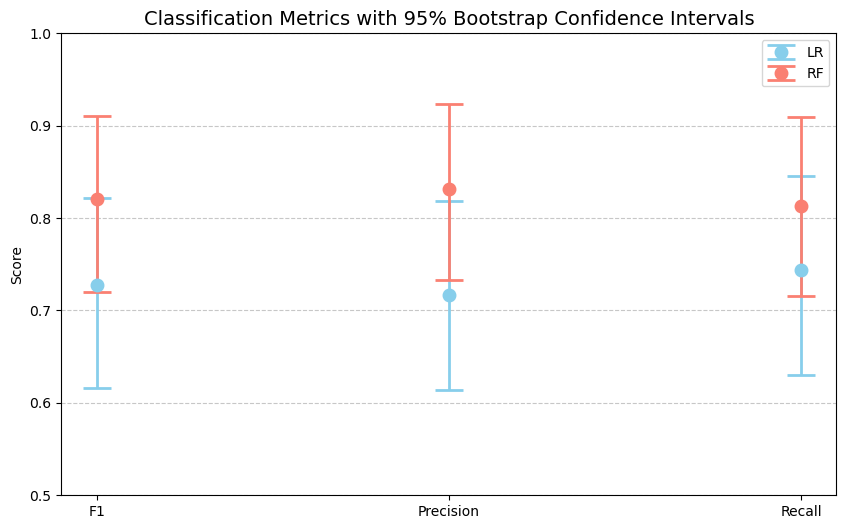

In [53]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
import matplotlib.pyplot as plt
import pandas as pd


data = {
    'Model': ['LR', 'LR', 'LR', 'RF', 'RF', 'RF'],
    'Metric': ['F1', 'Precision', 'Recall', 'F1', 'Precision', 'Recall'],
    'Estimate': [0.728, 0.717, 0.744, 0.821, 0.831, 0.813],
    'CI_Lower': [0.616, 0.614, 0.630, 0.720, 0.733, 0.716],
    'CI_Upper': [0.822, 0.818, 0.845, 0.911, 0.924, 0.909]
}

df_results = pd.DataFrame(data)

# Error bars
df_results['err_minus'] = df_results['Estimate'] - df_results['CI_Lower']
df_results['err_plus'] = df_results['CI_Upper'] - df_results['Estimate']

plt.figure(figsize=(10, 6))
metrics = df_results['Metric'].unique()
models = df_results['Model'].unique()
colors = {'LR': 'skyblue', 'RF': 'salmon'}

for i, model in enumerate(models):
    sub = df_results[df_results['Model'] == model]
    plt.errorbar(x=sub['Metric'], y=sub['Estimate'], 
                 yerr=[sub['err_minus'], sub['err_plus']],
                 fmt='o', capsize=10, elinewidth=2, markeredgewidth=2,
                 label=model, color=colors[model], markersize=8)

plt.title('Classification Metrics with 95% Bootstrap Confidence Intervals', fontsize=14)
plt.ylabel('Score')
plt.ylim(0.5, 1.0) # Aralığı fokuslamaq üçün
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

Model Selection: "Based on the bootstrap performance metrics, Random Forest should be deployed for predicting vehicle origin and fuel efficiency categories. Its ability to handle non-linear relationships and its superior F1-score (0.821) make it more reliable than linear models for this dataset."

Feature Engineering: "Future analyses should prioritize weight and horsepower as primary predictors. However, since Spearman correlation revealed non-linear trends, polynomial features or non-parametric models should be used to capture the complexity of engine efficiency accurately."

Regional Strategy: "Given that Japanese vehicles significantly outperform USA models in fuel efficiency (+10.42 MPG), American manufacturers should analyze Japanese engine architectures from the 1970s–80s to identify key efficiency-boosting engineering patterns that were absent in domestic models at that time."

Addressing Data Imbalance: "To improve the model’s ability to distinguish European cars, more balanced data collection or advanced synthetic oversampling (like SMOTE) is recommended, as the current model still shows slightly wider confidence intervals for minority classes."

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

This analysis examined the Auto MPG dataset to uncover the key drivers of fuel efficiency across 392 vehicles from three regions.
Correlation analysis revealed that weight (r = -0.83), displacement (r = -0.81), and horsepower (r = -0.78) are the strongest negative predictors of MPG — heavier, larger-engine vehicles consume significantly more fuel. Notably, several of these features exhibit high inter-correlation (e.g., displacement ↔ weight: 0.94), indicating multicollinearity that must be addressed before model building. The relationship between acceleration and MPG (r = 0.42) appeared weak, and partial correlation analysis suggested this is largely driven by model_year as a confounding variable rather than a direct mechanical relationship.
Regional ANOVA analysis confirmed that fuel efficiency differs significantly across origins (Kruskal-Wallis H = 132.09, p < 0.001, ε² = 0.33). Japanese vehicles outperform American vehicles by an average of 10.42 MPG — the largest gap observed. European vehicles also significantly outperform American ones (+7.57 MPG), while the Japan–Europe difference, though statistically significant (p = 0.020), is practically smaller at 2.85 MPG.
Classification results show that Random Forest outperforms Logistic Regression across all metrics. Bootstrap 95% CIs confirm this advantage: RF F1 [0.720, 0.911] vs LR F1 [0.616, 0.822]. Although the intervals partially overlap, RF's lower bound exceeds LR's lower bound by over 10 points, making it the recommended model — particularly given the dataset's class imbalance favoring USA vehicles.